In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

In [2]:
# Config

DATA_PATH = "../backend/data/D1_sensor_data.csv"
PLOT_MINIMAL = True  

In [3]:
# Helpers

def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    print("Loaded:", path)
    print("Shape:", df.shape)
    return df

def validate_schema(df: pd.DataFrame) -> None:
    required = [
        "published_at", "tag_number",
        "temperature", "humidity", "hive_power",
        "audio_density", "audio_density_ratio", "density_variation",
        "lat", "long"
    ]
    missing = [c for c in required if c not in df.columns]
    assert not missing, f"Missing required columns: {missing}"

def parse_timestamps(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["published_at"] = pd.to_datetime(df["published_at"], utc=True, errors="coerce")
    bad = df["published_at"].isna().sum()
    print("Invalid timestamps:", bad)
    assert bad == 0, "Some published_at values could not be parsed."
    return df

def identify_column_groups(df: pd.DataFrame):
    hz_cols = [c for c in df.columns if c.startswith("hz_")]
    env_cols = ["temperature", "humidity", "hive_power"]
    audio_cols = ["audio_density", "audio_density_ratio", "density_variation"]
    meta_cols = [c for c in ["tag_number", "beehub_name", "geolocation", "lat", "long"] if c in df.columns]
    return hz_cols, env_cols, audio_cols, meta_cols


In [4]:
#  Load + validate

df_raw = load_data(DATA_PATH)
df = df_raw.copy()

validate_schema(df)
df = parse_timestamps(df)

hz_cols, env_cols, audio_cols, meta_cols = identify_column_groups(df)

print("\nColumn groups:")
print("  env_cols:", env_cols)
print("  audio_cols:", audio_cols)
print("  hz_cols_count:", len(hz_cols))
print("  meta_cols:", meta_cols)

print("\nSample rows:")
display(df[["published_at", "tag_number"] + env_cols + audio_cols].head(5))

print("\nUnique hives:", df["tag_number"].nunique())

Loaded: ../backend/data/D1_sensor_data.csv
Shape: (960809, 30)
Invalid timestamps: 0

Column groups:
  env_cols: ['temperature', 'humidity', 'hive_power']
  audio_cols: ['audio_density', 'audio_density_ratio', 'density_variation']
  hz_cols_count: 16
  meta_cols: ['tag_number', 'beehub_name', 'geolocation', 'lat', 'long']

Sample rows:


,published_at,tag_number,temperature,humidity,hive_power,audio_density,audio_density_ratio,density_variation
0,2020-04-16 04:30:37+00:00,200602,19.98,38.46,-7.518,12.86,0.875,37.33
1,2020-04-16 04:45:37+00:00,200602,19.96,38.47,-4.783,-4.64,0.890,10.75
2,2020-04-16 05:00:37+00:00,200602,19.95,38.47,-9.349,-7.06,0.843,12.70
3,2020-04-16 05:15:37+00:00,200602,19.93,38.50,-10.000,-6.94,0.847,11.35
4,2020-04-16 05:30:37+00:00,200602,19.93,38.50,-10.000,-6.88,0.835,13.10



Unique hives: 85


In [5]:
#  NaN missingness (true NaNs)

OBS_COLS = env_cols + audio_cols + hz_cols

nan_missing_pct = (df[OBS_COLS].isna().mean() * 100).sort_values(ascending=False)
nan_summary = pd.DataFrame({"missing_pct": nan_missing_pct})

rows_any_nan_pct = df[OBS_COLS].isna().any(axis=1).mean() * 100
rows_all_nan_pct = df[OBS_COLS].isna().all(axis=1).mean() * 100

print("\nNaN missingness summary (top 10):")
display(nan_summary.head(10))
print(f"% rows with ANY NaN in obs cols: {rows_any_nan_pct:.3f}%")
print(f"% rows FULLY NaN across obs cols: {rows_all_nan_pct:.3f}%")

if nan_summary["missing_pct"].max() == 0:
    print(" No NaN missingness detected.")
    print("Missingness appears encoded via sentinel placeholders (e.g., hive_power=-10) and duplicates (checked below).")



NaN missingness summary (top 10):


,missing_pct
temperature,0.0
humidity,0.0
hive_power,0.0
audio_density,0.0
audio_density_ratio,0.0
density_variation,0.0
hz_122.0703125,0.0
hz_152.587890625,0.0
hz_183.10546875,0.0
hz_213.623046875,0.0


% rows with ANY NaN in obs cols: 0.000%
% rows FULLY NaN across obs cols: 0.000%
 No NaN missingness detected.
Missingness appears encoded via sentinel placeholders (e.g., hive_power=-10) and duplicates (checked below).


In [6]:
#  Implicit / sentinel missingness 

implicit = {
    "hive_power == -10 (%)": float((df["hive_power"].eq(-10)).mean() * 100),
    "lat & long == 0,0 (%)": float(((df["lat"].eq(0)) & (df["long"].eq(0))).mean() * 100),
    "duplicate (hive,timestamp) (%)": float((df.duplicated(subset=["tag_number", "published_at"])).mean() * 100),
}

implicit_df = pd.DataFrame([implicit])

print("\nImplicit missingness / data quality signals (%):")
display(implicit_df)



Implicit missingness / data quality signals (%):


,hive_power == -10 (%),"lat & long == 0,0 (%)","duplicate (hive,timestamp) (%)"
0,32.760934,31.255848,46.175775


In [7]:

#  Duplicates & conflicts 

dup_exact = int(df.duplicated().sum())
dup_global_ts = int(df["published_at"].duplicated().sum())
dup_per_hive_ts = int(df.duplicated(subset=["tag_number", "published_at"]).sum())

dup_keys = df[df.duplicated(subset=["tag_number", "published_at"], keep=False)].copy()

conflict_pct = 0.0
if len(dup_keys) > 0:
    numeric_cols = env_cols + audio_cols + hz_cols
    nunique_per_key = dup_keys.groupby(["tag_number", "published_at"])[numeric_cols].nunique(dropna=False)
    conflicting = (nunique_per_key > 1).any(axis=1)
    conflict_pct = float(conflicting.mean() * 100)

dup_summary = pd.DataFrame([{
    "duplicate rows (exact)": dup_exact,
    "duplicate timestamps (global)": dup_global_ts,
    "duplicate timestamps (per hive)": dup_per_hive_ts,
    "rows involved in dup keys": int(len(dup_keys)),
    "conflicting duplicate keys (%)": conflict_pct
}])

print("\nDuplicates / conflicts summary:")
display(dup_summary)


Duplicates / conflicts summary:


,duplicate rows (exact),duplicate timestamps (global),duplicate timestamps (per hive),rows involved in dup keys,conflicting duplicate keys (%)
0,122351,455641,443661,505248,38.613668



Delta time (minutes) summary:


count    960724.000000
mean         12.771843
std         467.397498
min           0.000000
25%           0.000000
50%          15.000000
75%          15.150000
max      127466.966667
Name: dt_min, dtype: float64


Top 15 sampling intervals (minutes):


,dt_min,count
0,0.000000,443661
1,15.000000,217499
2,15.166667,55803
3,15.150000,42098
4,15.183333,39752
5,15.200000,28920
6,15.216667,18682
7,15.233333,9357
8,15.133333,8448
9,16.283333,7982



Top 10 hives by large gap % (>30 min):


tag_number
200752    22.222222
200726    16.666667
202047     4.569191
202209     2.221149
202210     2.199806
202046     1.832099
202065     1.811507
202067     1.795496
202052     1.775946
202211     1.769156
Name: dt_min, dtype: float64


Top 10 hives by maximum gap (minutes):


tag_number
202213    127466.966667
202046    118833.583333
202054    118695.200000
202210    118575.150000
202209    118546.266667
202129    101391.666667
202071     81059.366667
202073     80595.200000
202215     80297.183333
202214     80209.800000
Name: dt_min, dtype: float64

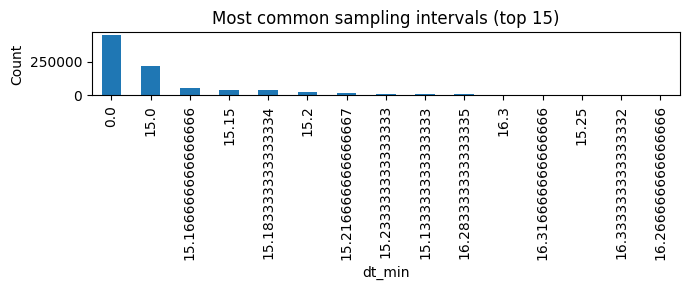

In [ ]:
#  Sampling interval & gaps 

df_sorted = df.sort_values(["tag_number", "published_at"]).copy()
df_sorted["dt_min"] = (
    df_sorted.groupby("tag_number")["published_at"]
    .diff()
    .dt.total_seconds() / 60
)

print("\nDelta time (minutes) summary:")
display(df_sorted["dt_min"].describe())

top_dt = df_sorted["dt_min"].value_counts().head(15)
top_dt_df = top_dt.rename("count").reset_index().rename(columns={"index": "dt_min"})

print("\nTop 15 sampling intervals (minutes):")
display(top_dt_df)

large_gap_pct = (df_sorted["dt_min"] > 30).groupby(df_sorted["tag_number"]).mean() * 100
max_gap_min = df_sorted.groupby("tag_number")["dt_min"].max()

print("\nTop 10 hives by large gap % (>30 min):")
display(large_gap_pct.sort_values(ascending=False).head(10))

print("\nTop 10 hives by maximum gap (minutes):")
display(max_gap_min.sort_values(ascending=False).head(10))

# Plot 2 
if PLOT_MINIMAL:
    ax = top_dt.plot(kind="bar", figsize=(7,3))
    ax.set_title("Most common sampling intervals (top 15)")
    ax.set_ylabel("Count")
    ax.set_xlabel("dt_min")
    plt.tight_layout()
    plt.show()


In [9]:
#  Minimal per-hive quality snapshot 

quality = pd.DataFrame({
    "rows": df.groupby("tag_number").size(),
    "unique_timestamps": df.groupby("tag_number")["published_at"].nunique(),
    "dup_ts_count": df.duplicated(subset=["tag_number", "published_at"]).groupby(df["tag_number"]).sum(),
    "hive_power_-10_pct": (df["hive_power"].eq(-10)).groupby(df["tag_number"]).mean() * 100,
    "geo_0_0_pct": ((df["lat"].eq(0)) & (df["long"].eq(0))).groupby(df["tag_number"]).mean() * 100,
    "large_gap_pct": large_gap_pct,
    "max_gap_min": max_gap_min
}).fillna(0).sort_values("rows", ascending=False)

print("\nPer-hive quality (top 10 by rows):")
display(quality.head(10))

print("\nPer-hive quality (top 10 by dup timestamps):")
display(quality.sort_values("dup_ts_count", ascending=False).head(10))



Per-hive quality (top 10 by rows):


,rows,unique_timestamps,dup_ts_count,hive_power_-10_pct,geo_0_0_pct,large_gap_pct,max_gap_min
tag_number,,,,,,,
200684,30593,3,30590,75.723205,100.000000,0.003269,30652.933333
200894,29412,10,29402,68.665851,100.000000,0.003400,76.233333
201382,28223,9,28214,77.876200,100.000000,0.003543,30653.183333
200597,21012,1,21011,69.902913,100.000000,0.000000,0.000000
200712,20912,4,20908,44.663351,100.000000,0.004782,46.900000
200517,20607,4,20603,67.316931,100.000000,0.000000,15.000000
200957,20315,16,20299,12.000984,100.000000,0.009845,50.316667
202131,16714,8636,8078,3.356468,0.789757,0.688046,22599.350000
202065,16616,12846,3770,20.227492,1.582812,1.811507,22717.666667



Per-hive quality (top 10 by dup timestamps):


,rows,unique_timestamps,dup_ts_count,hive_power_-10_pct,geo_0_0_pct,large_gap_pct,max_gap_min
tag_number,,,,,,,
200684,30593,3,30590,75.723205,100.0,0.003269,30652.933333
200894,29412,10,29402,68.665851,100.0,0.003400,76.233333
201382,28223,9,28214,77.876200,100.0,0.003543,30653.183333
200597,21012,1,21011,69.902913,100.0,0.000000,0.000000
200712,20912,4,20908,44.663351,100.0,0.004782,46.900000
200517,20607,4,20603,67.316931,100.0,0.000000,15.000000
200957,20315,16,20299,12.000984,100.0,0.009845,50.316667
200659,13229,5,13224,67.805579,100.0,0.007559,30866.033333
200433,13001,6,12995,68.402431,100.0,0.015383,6722.133333


In [10]:
#  summary 

summary = {
    "rows_total": int(len(df)),
    "cols_total": int(df.shape[1]),
    "unique_hives": int(df["tag_number"].nunique()),
    "hz_cols_count": int(len(hz_cols)),
    "nan_rows_any_pct": float(rows_any_nan_pct),
    "implicit_hive_power_-10_pct": implicit["hive_power == -10 (%)"],
    "implicit_geo_0_0_pct": implicit["lat & long == 0,0 (%)"],
    "duplicate_timestamps_per_hive": int(dup_per_hive_ts),
    "conflicting_duplicate_keys_pct": float(conflict_pct),
    "dominant_sampling_intervals_top5": top_dt.head(5).to_dict(),
}

print("\n FINAL SUMMARY ")
for k, v in summary.items():
    print(f"{k}: {v}")




 FINAL SUMMARY 
rows_total: 960809
cols_total: 30
unique_hives: 85
hz_cols_count: 16
nan_rows_any_pct: 0.0
implicit_hive_power_-10_pct: 32.76093375478373
implicit_geo_0_0_pct: 31.25584793647853
duplicate_timestamps_per_hive: 443661
conflicting_duplicate_keys_pct: 38.61366846899508
dominant_sampling_intervals_top5: {0.0: 443661, 15.0: 217499, 15.166666666666666: 55803, 15.15: 42098, 15.183333333333334: 39752}
